In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from reinforcement_learning.agent import Agent
from reinforcement_learning.action import Action
from reinforcement_learning.action_selection import GradientBandit

In [2]:
n_runs = 2000
n_steps_per_run = 1000
optimal_actions_per_run_per_agent = [[], [], [], []]

for irun in range(n_runs):
    actions = [Action.gaussian(4, 1) for i in range(10)]
    agents = [
        Agent(*actions, action_selection_method=GradientBandit(alpha=0.1, baseline=0)),
        Agent(*actions, action_selection_method=GradientBandit(0.1, baseline=4)),
        Agent(*actions, action_selection_method=GradientBandit(0.4, baseline=0)),
        Agent(*actions, action_selection_method=GradientBandit(0.4, baseline=4))
        ]
    for i, agent in enumerate(agents):
        # print(agent.optimal_action)
        for istep in range(n_steps_per_run):
            agent.act()
        optimal_actions_per_run_per_agent[i].append(np.array(agent.experience.action_history) == agent.optimal_action)
optimal_actions_per_run_per_agent = np.array(optimal_actions_per_run_per_agent)

In [3]:
optimal_action_cumsum_per_run_per_agent = np.cumsum(optimal_actions_per_run_per_agent, axis=1)

In [4]:
mean_optimal_action_per_agent = np.mean(optimal_action_cumsum_per_run_per_agent, axis=1)

In [7]:
reward_df = pd.DataFrame({'mean_optimal_action': mean_optimal_action_per_agent.reshape(-1),
                          'action_selection': pd.Categorical([a for action_selection in ['alpha=0.1, no baseline',
                                                                                         'alpha=0.1, with baseline',
                                                                                         'alpha=0.4, no baseline',
                                                                                         'alpha=0.4, with baseline'] for a in [action_selection] * n_steps_per_run]),
                          'step': [i for _ in range(4) for i in range(n_steps_per_run)]})

<Axes: xlabel='step', ylabel='mean_optimal_action'>

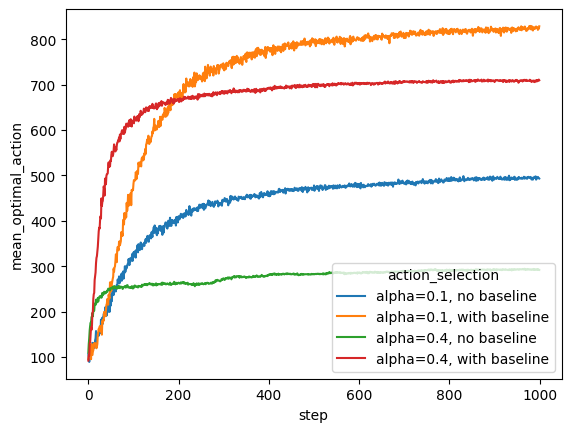

In [8]:
sns.lineplot(reward_df, x='step', y='mean_optimal_action', hue='action_selection')